# Tree boosting main idea
## Data
- Source: [https://www.kaggle.com/datasets/mirichoi0218/insurance]
- Individual medical costs billed by health insurance
- EDA: e.g [https://datauab.github.io/medical_insurance/]
- Preprocessed, split into training and test set and saved in pickle file

## Task
- Develop a toy bossting machine to model
- One dimensional relation
- Target: charges
- Feature: bmi 

In [1]:
### Dependencies
import numpy as np
import matplotlib.pyplot as plt #basic graphs
import pandas as pd
import pickle

# Used models
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error # MSE
from sklearn.tree import plot_tree #tree to plot tree

SEED = 500

In [ ]:
# import gdown
#In colab, you need to download the file first and save it locally 
# file_id = '1ZHg2xs5ekH1XKzcvbJBkkqcHIl4J9mD9' #insurance.pkl
# file_path = 'insurance_train_test.pkl'
# gdown.download('https://drive.google.com/uc?id={}'.format(file_id), file_path, quiet=False)

In [2]:
#Load the file
#for local installation / VM horizon
file_path = '../data/insurance_train_test.pkl'

#load data (already split into training and validation)
with open(file_path, "rb") as input_file:
    X_train, X_test, y_train, y_test = pickle.load(input_file)
    
    
#Alias for columns
y = 'charges' #response
x = 'bmi' #feature

In [3]:
display(X_train)

,age,bmi,children,sex_male,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
381,55,30.7,0,True,True,True,False,False,False
959,48,36.7,1,True,False,False,True,False,False
526,19,30.6,2,False,False,False,True,False,False
1016,19,24.6,1,False,False,False,True,False,False
1032,30,27.9,0,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...
287,63,26.2,0,False,False,False,True,False,False
957,24,26.8,1,True,False,False,True,False,False
273,50,27.5,1,True,False,True,False,False,False
951,51,42.9,2,True,True,False,False,True,False


In [4]:
#Select only smokers for training
dat = pd.concat([X_train[x], y_train], axis=1)
dat = dat.loc[X_train['smoker_yes'] == 1, :]
dat = dat.sort_values(x)
dat.head()
#Mean of charges
mean_y = _____ #dat[y].mean()
print('Mean charges for smokers: ', mean_y)

#Scatter plot
plt.scatter(dat[x], dat[y], color='red')
plt.xlabel(x)
plt.ylabel(y)
plt.title('Charges vs BMI for smokers')
#add horizontal line for mean
plt.axhline(y=mean_y, color='b', linestyle='-')
plt.show()




NameError: name '_____' is not defined

In [107]:
#Do the same for test data that we will use for validation
dat_valid = pd.concat([X_test[x], y_test], axis=1)
dat_valid = dat_valid.loc[X_test['smoker_yes'] == 1, :]
dat_valid = dat_valid.sort_values(x)
dat_valid.head()


,bmi,charges
380,18.0,15006.58
1100,19.1,16776.30
994,20.0,16420.49
793,20.9,21195.82
1306,21.9,16115.30


In [ ]:
i_run = 0 #initial model 
dat["pred"+str(i_run)] = _____ #mean_y - constant initial model
#validation sample - predicted with training mean
dat_valid["pred"+str(i_run)] = _____

#calculate mse of the initial model
mse_boosters = [mean_squared_error(dat[y], dat['pred'+str(i_run)])]
print('MSE for initial model: ', mse_boosters[-1])

#calculate mse of the initial model on validation
mse_boosters_valid = [mean_squared_error(dat_valid[y], dat_valid['pred'+str(i_run)])]
print('MSE for initial model on validation: ', mse_boosters_valid[-1])


MSE for initial model:  135195077.85028267
MSE for initial model on validation:  122507673.0407536


<font color='DodgerBlue'>
Perform 10 iterations of boosting and collect MSE for training and validation set for each iteration: <br>
<ol>
<li> Calculate <b>residuals</b> (The difference between the response variable and the current predictions) for the training data.
<li> <b>Fit a decision tree to the residuals.</b> Use only a stump (max_depth=1). Other HP remain default.
<li> Calculate the <b>predictions</b> of the <b>residulas</b> using the new model, for boths training and validation data.
<li> <b>Update current predictions</b> of the model by adding the predictions of the new residual model (=add new basis) for both training and validation data. 
<li> <b>Update MSE</b> for training and validation data. 
<li> Draw some plots to see what is going on during first 5 iterations. 
</ol>
</font>

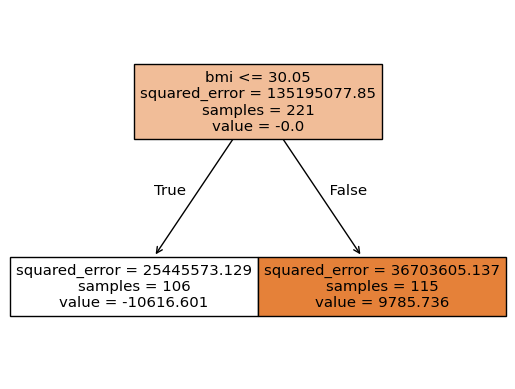

<Figure size 640x480 with 0 Axes>

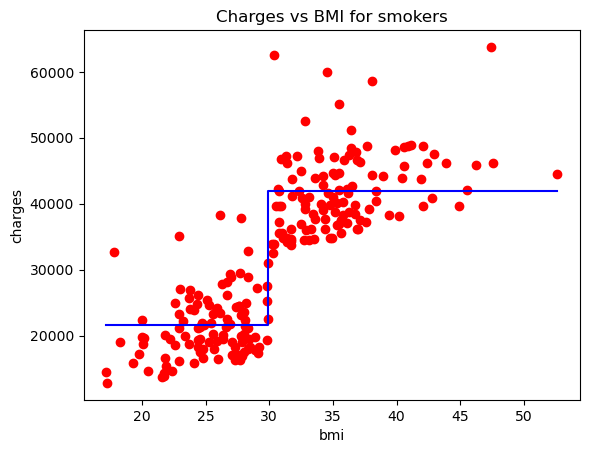

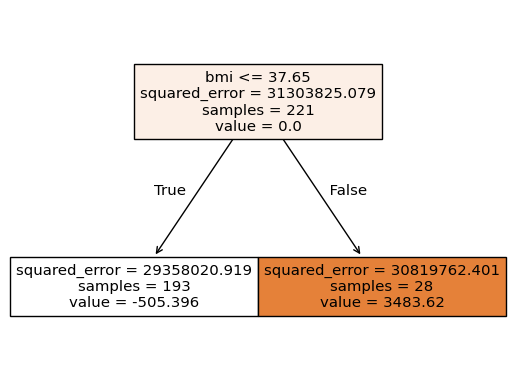

<Figure size 640x480 with 0 Axes>

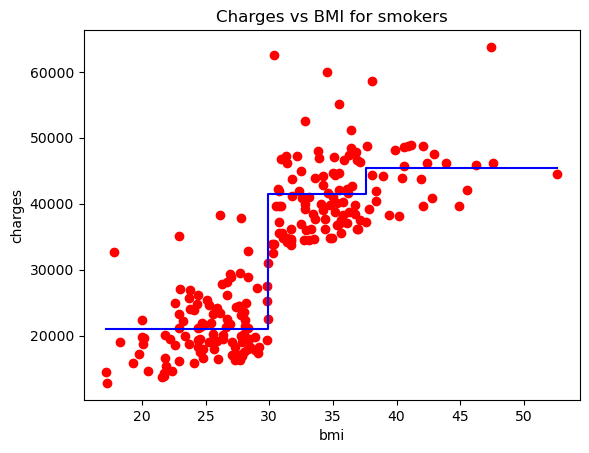

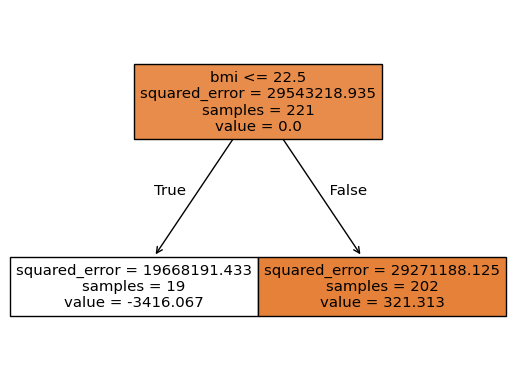

<Figure size 640x480 with 0 Axes>

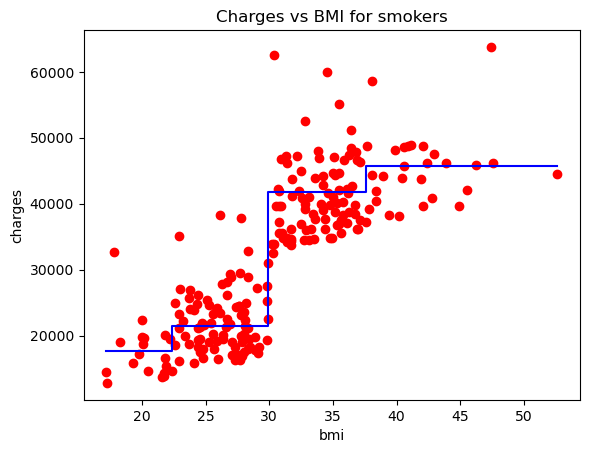

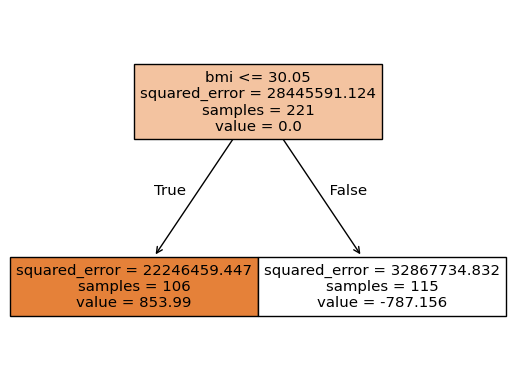

<Figure size 640x480 with 0 Axes>

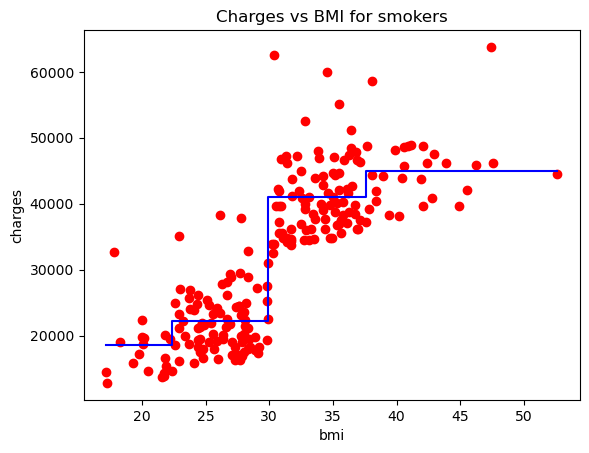

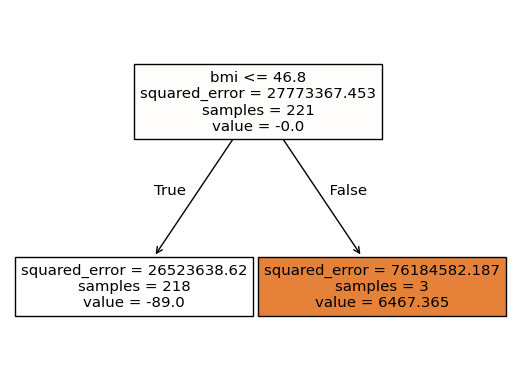

<Figure size 640x480 with 0 Axes>

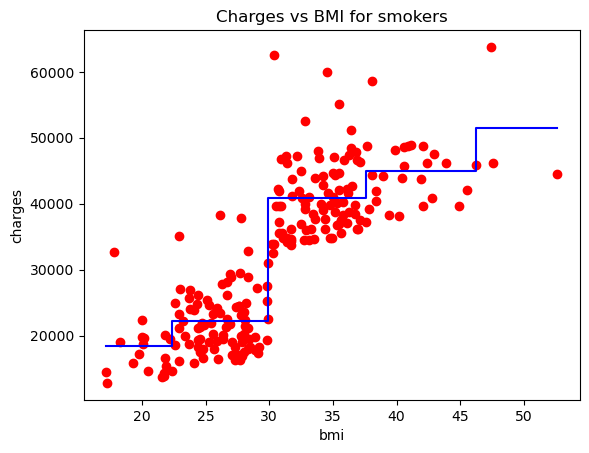

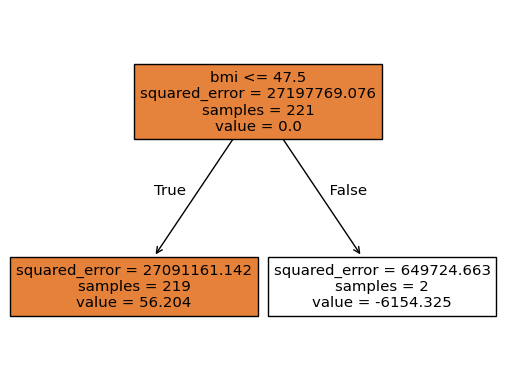

<Figure size 640x480 with 0 Axes>

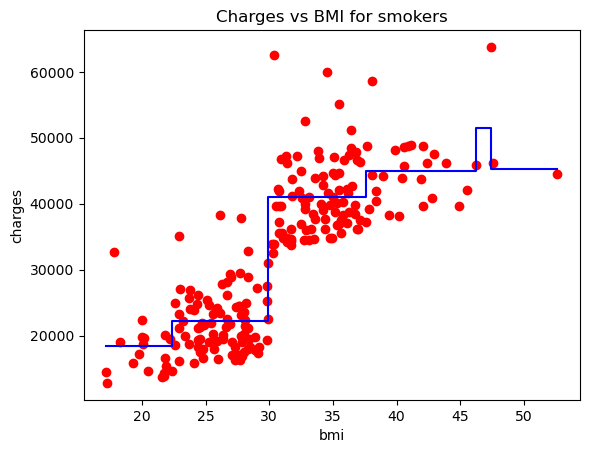

In [ ]:
nBoost = 10
nPlotBoost = 5 #plot max iteratons

for i_run in range(nBoost):



<font color='DodgerBlue'>
<b>Plot MSE</b> for training and validation data for each iteration. <br>
Find the <b>optimal number of iterations</b>. <br>
<b> Create boxplots for residuals</b> for first 5 iterations. What is going on with its variance? <br>
</font>

Minimum MSE:22551891.15 
Minimum MSE index (iteration):  7


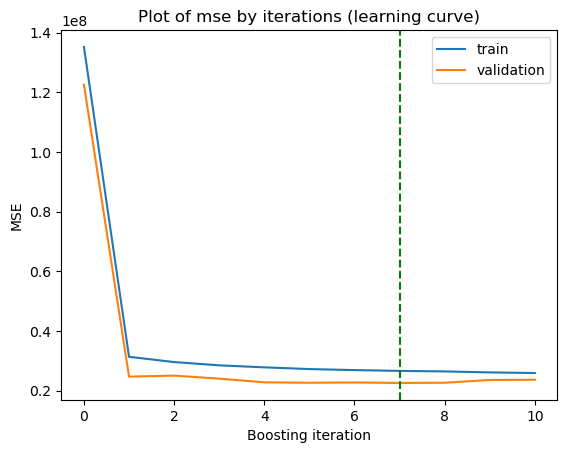

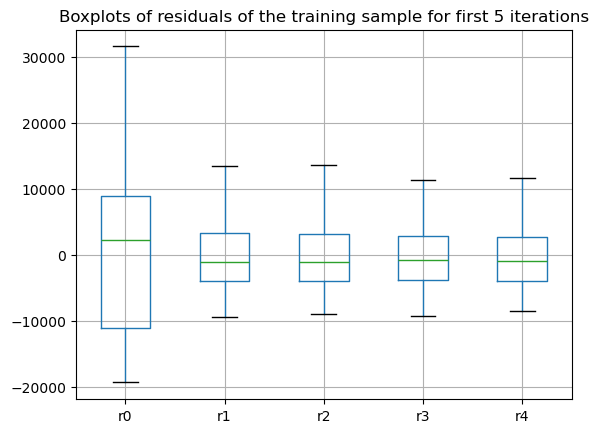

In [ ]:
#plot decrease of mse over iterations


#Find minimum for validation sample


#Add vertical line at the minimum


#plot boxplots of residuals (r0, r1, ...). Ignore outliers using showfliers=False





<font color='DodgerBlue'>
<b>Task:</b> <br>
Release the constraint of max_depth=1 and <b>fit a tree with max_depth=3</b>. <br>
Plot MSE for training and validation data for each iteration. <br>
Find the optimal number of iterations. <br>
<b>Compare the results</b> with the previous model. <br>
</font>

In [ ]:
#Use the code you developed. You can just change the HP of the tree.

Minimum MSE:21228023.56 
Minimum MSE index:  1


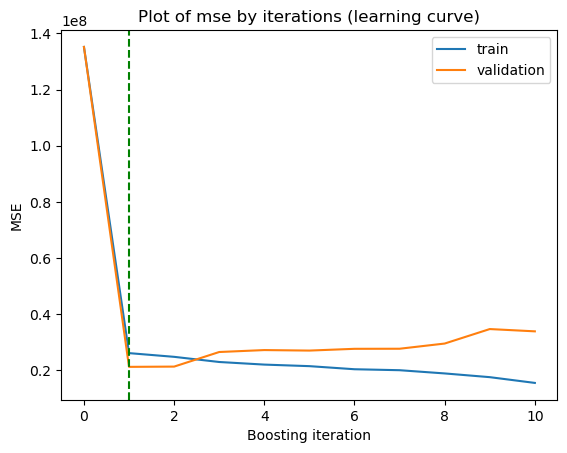

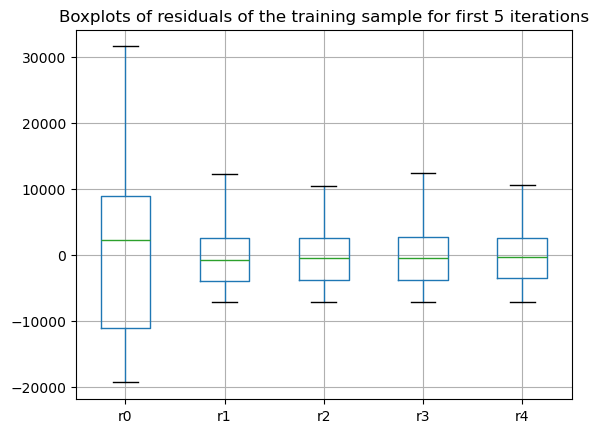

In [ ]:
#plot decrease of mse over iterations



#Find minimum for validation sample


#Add vertical line at the minimum


#plot boxplots of residuals (r0, r1, ...). Ignore outliers using showfliers=False


We used a <b>more complex booster</b> as we set max_depth = 3 instead of the original max_depth = 1 ("stump"). Therefore the <b>number of iterations</b> to achieve a minimum is much <b>lower</b> than before. The MSE is almost the same.<br>

<font color='DodgerBlue'>
<b>Quastion 1</b>: The number of iterations in the second model is much lower. Does this automatically mean that fitting will take lower time? <br>
<b>Answer 1</b>: Automatically no, as fitting more complex trees in each iteration will take more time than in the case of stumps. <br>
</font>

The tree complexity (given e.g. by the max_depth) and the number of iterations are <b>hyper-parameters</b> of the model and should be optimized for example using a grid.